# Day 6: Chroma

Chroma is an open-source AI-native vector database designed for building LLM applications. Unlike every library we have used so far, Chroma is not just a search index - it is a persistent, queryable store with built-in metadata filtering, document storage and collection management. You can think of it as the bridge between a vector search library and a full vector database.

Chroma runs embedded in your Python process with no server required, which is what makes it relevant in a book about Python vector search libraries. In embedded mode it feels like a library - you import it, create a collection and query it. But underneath it manages persistence, indexing and metadata automatically in a way that none of the previous libraries do.

## When would you reach for Chroma?

Chroma is the right choice when:

- You are building a RAG pipeline and need a persistent store that survives process restarts
- You need metadata filtering alongside vector search - filter by crime type, neighborhood or date before searching
- You want to store documents and embeddings together rather than managing them separately
- You want a simple local development experience that scales to a hosted service without code changes

## The use case

We load the Nordvik crime dataset into Chroma with full metadata, then demonstrate three things the previous libraries could not do: metadata filtering, hybrid search and a simple RAG pipeline over crime incidents. We also measure recall and latency against the ground truth for a direct comparison with previous days.

## 1. Install Dependencies

In [1]:
%pip install chromadb==1.5.9 \
             numpy==2.2.6 \
             pandas==3.0.3 \
             plotly==6.9.0 \
             pyarrow==25.0.0 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [2]:
import chromadb
import numpy as np
import os
import pandas as pd
import plotly.graph_objects as go
import time

print(f"OK  Chroma version: {chromadb.__version__}")

OK  Chroma version: 1.5.9


## 3. Load Data and Embeddings

In [3]:
df         = pd.read_parquet("data/nordvik_crimes.parquet")
embeddings = np.load("data/nordvik_embeddings.npy").astype("float32")
ids        = np.loadtxt("data/nordvik_ids.txt", dtype = str, encoding = "utf-8")

ground_truth   = np.load("data/nordvik_ground_truth.npy")
sample_indices = np.load("data/nordvik_ground_truth_indices.npy")
query_sample   = embeddings[sample_indices]

DIM = embeddings.shape[1]
K   = 10

print(f"OK  Dataset:      {len(df):,} rows")
print(f"OK  Embeddings:   {embeddings.shape} {embeddings.dtype}")
print(f"OK  Ground truth: {ground_truth.shape} ({len(sample_indices):,} sampled queries)")

OK  Dataset:      500,000 rows
OK  Embeddings:   (500000, 384) float32
OK  Ground truth: (1000, 10) (1,000 sampled queries)


## 4. Create a Persistent Chroma Client and Collection

We use `PersistentClient` so the collection survives process restarts. Chroma stores everything in a local directory - embeddings, documents and metadata - with no external service required.

We pass `embedding_function=None` and supply our own precomputed embeddings. This keeps the embedding model consistent with every other chapter in the book.

In [4]:
CHROMA_PATH = "data/nordvik_chroma"
COLLECTION  = "nordvik_crimes"

client = chromadb.PersistentClient(path = CHROMA_PATH)

# Delete collection if it already exists so we start clean
try:
    client.delete_collection(COLLECTION)
    print("OK  Existing collection deleted")
except Exception:
    pass

collection = client.create_collection(
    name = COLLECTION,
    metadata = {"hnsw:space": "cosine"},
)

print(f"OK  Collection created: {COLLECTION}")
print(f"    Persisted at: {CHROMA_PATH}")

OK  Existing collection deleted
OK  Collection created: nordvik_crimes
    Persisted at: data/nordvik_chroma


## 5. Add Documents in Batches

Chroma accepts documents, embeddings, metadata and IDs together. We store the MO_TEXT as the document and include crime type, neighborhood, datetime and weapon as metadata fields - all of which become filterable at query time.

We add in batches of 5,000 to avoid memory pressure.

In [5]:
from tqdm.notebook import tqdm

BATCH_SIZE = 5_000
n_batches  = (len(df) + BATCH_SIZE - 1) // BATCH_SIZE

print(f"OK  Adding {len(df):,} documents in batches of {BATCH_SIZE:,}...")
start = time.perf_counter()

for batch_num in tqdm(range(n_batches), desc = "Adding to Chroma"):
    start_idx = batch_num * BATCH_SIZE
    end_idx   = min(start_idx + BATCH_SIZE, len(df))
    batch_df  = df.iloc[start_idx:end_idx]

    collection.add(
        ids        = batch_df["IncidentID"].tolist(),
        embeddings = embeddings[start_idx:end_idx].tolist(),
        documents  = batch_df["MO_TEXT"].tolist(),
        metadatas  = batch_df[[
            "CrimeType", "CrimeSubType", "Neighborhood",
            "DateTime", "Weapon", "PropertyStolen",
        ]].to_dict("records"),
    )

elapsed = time.perf_counter() - start
print(f"\nOK  All documents added ({elapsed:.1f}s)")
print(f"    Collection count: {collection.count():,}")

OK  Adding 500,000 documents in batches of 5,000...


Adding to Chroma:   0%|          | 0/100 [00:00<?, ?it/s]


OK  All documents added (321.5s)
    Collection count: 500,000


## 6. Basic Vector Search

Standard nearest neighbor search using precomputed embeddings - comparable to what we have done in every previous chapter.

In [6]:
QUERY_IDX = df[df["CrimeType"] == "Burglary"].index[0]
query_vec = embeddings[QUERY_IDX].tolist()

print(f"Query incident: {df['IncidentID'].iloc[QUERY_IDX]}")
print(f"Crime type:     {df['CrimeType'].iloc[QUERY_IDX]}")
print(f"MO_TEXT:        {df['MO_TEXT'].iloc[QUERY_IDX]}")
print()

N_REPEATS = 50
times     = []

for _ in range(N_REPEATS):
    start = time.perf_counter()
    results = collection.query(
        query_embeddings = [query_vec],
        n_results = K,
        include = ["documents", "metadatas", "distances"],
    )
    times.append((time.perf_counter() - start) * 1000)

latency = float(np.mean(times))

print(f"OK  Query complete ({latency:.3f}ms avg over {N_REPEATS} runs)\n")
print(f"{'Rank':<6} {'IncidentID':<14} {'CrimeType':<16} {'Distance':<10} {'MO_TEXT'}")
print("-" * 90)
for rank, (doc_id, meta, dist, doc) in enumerate(
    zip(
        results["ids"][0],
        results["metadatas"][0],
        results["distances"][0],
        results["documents"][0],
    ), 1
):
    print(f"{rank:<6} {doc_id:<14} {meta['CrimeType']:<16} {dist:<10.4f} {doc[:60]}...")

Query incident: NVK-000004
Crime type:     Burglary
MO_TEXT:        At approx 1632hrs, Multiple offenders described as medium build, tall, wearing face covering gained entry to Residence - Single Family in Hartley Cross. Property taken: handbag, tablet. No FO identified.

OK  Query complete (0.773ms avg over 50 runs)

Rank   IncidentID     CrimeType        Distance   MO_TEXT
------------------------------------------------------------------------------------------
1      NVK-000004     Burglary         -0.0000    At approx 1632hrs, Multiple offenders described as medium bu...
2      NVK-429593     Burglary         0.1416     Multiple offenders described as slim build, tall, wearing hi...
3      NVK-090521     Burglary         0.1418     Multiple offenders described as medium build, average, weari...
4      NVK-071545     Burglary         0.1484     Residence - Single Family in Hartley Cross targeted. Items r...
5      NVK-059565     Burglary         0.1507     Multiple offenders descri

## 7. Metadata Filtering

This is Chroma's key differentiator from pure vector libraries. We can filter by any metadata field before or alongside the vector search. Here we search for similar incidents but restrict results to specific crime types, neighborhoods and date ranges - operations that would require post-processing in FAISS, Voyager or PyNNDescent.

In [7]:
# Filter 1 - burglary only
results_burglary = collection.query(
    query_embeddings = [query_vec],
    n_results = K,
    where = {"CrimeType": {"$eq": "Burglary"}},
    include = ["documents", "metadatas", "distances"],
)

print("Results filtered to Burglary only:\n")
for rank, (doc_id, meta, dist) in enumerate(
    zip(results_burglary["ids"][0], results_burglary["metadatas"][0], results_burglary["distances"][0]), 1
):
    print(f"  {rank}. {doc_id} [{meta['CrimeType']}] [{meta['Neighborhood']}] dist={abs(dist):.4f}")

Results filtered to Burglary only:

  1. NVK-000004 [Burglary] [Hartley Cross] dist=-0.0000
  2. NVK-429593 [Burglary] [Hartley Cross] dist=0.1416
  3. NVK-090521 [Burglary] [Hartley Cross] dist=0.1418
  4. NVK-071545 [Burglary] [Hartley Cross] dist=0.1484
  5. NVK-059565 [Burglary] [Hartley Cross] dist=0.1507
  6. NVK-295844 [Burglary] [Hartley Cross] dist=0.1553
  7. NVK-487821 [Burglary] [Hartley Cross] dist=0.1583
  8. NVK-434251 [Burglary] [Hartley Cross] dist=0.1591
  9. NVK-421978 [Burglary] [Hartley Cross] dist=0.1598
  10. NVK-025362 [Burglary] [Hartley Cross] dist=0.1638


In [8]:
# Filter 2 - armed incidents only (weapon not 'none')
results_armed = collection.query(
    query_embeddings = [query_vec],
    n_results = K,
    where = {"Weapon": {"$ne": "none"}},
    include = ["documents", "metadatas", "distances"],
)

print("Results filtered to armed incidents only:\n")
for rank, (doc_id, meta, dist) in enumerate(
    zip(results_armed["ids"][0], results_armed["metadatas"][0], results_armed["distances"][0]), 1
):
    print(f"  {rank}. {doc_id} [{meta['CrimeType']}] weapon={meta['Weapon']} dist={abs(dist):.4f}")

Results filtered to armed incidents only:

  1. NVK-090521 [Burglary] weapon=baseball bat dist=0.1418
  2. NVK-059565 [Burglary] weapon=craft knife dist=0.1507
  3. NVK-487821 [Burglary] weapon=kitchen knife dist=0.1583
  4. NVK-434251 [Burglary] weapon=craft knife dist=0.1591
  5. NVK-331119 [Other] weapon=craft knife dist=0.1615
  6. NVK-025362 [Burglary] weapon=baseball bat dist=0.1638
  7. NVK-055639 [Robbery] weapon=firearm dist=0.1645
  8. NVK-161855 [Robbery] weapon=kitchen knife dist=0.1646
  9. NVK-113626 [Burglary] weapon=screwdriver dist=0.1667
  10. NVK-123098 [Burglary] weapon=craft knife dist=0.1669


In [9]:
# Filter 3 - specific neighborhood
results_neighborhood = collection.query(
    query_embeddings = [query_vec],
    n_results = K,
    where = {"Neighborhood": {"$eq": "Millfield"}},
    include = ["documents", "metadatas", "distances"],
)

print("Results filtered to Millfield only:\n")
for rank, (doc_id, meta, dist) in enumerate(
    zip(results_neighborhood["ids"][0], results_neighborhood["metadatas"][0], results_neighborhood["distances"][0]), 1
):
    print(f"  {rank}. {doc_id} [{meta['CrimeType']}] [{meta['Neighborhood']}] dist={abs(dist):.4f}")

print("")
print("Note: distances are higher (0.34+) than the unfiltered results (0.14+).")
print("Geographic filtering constrains the candidate set, so the closest semantic")
print("matches within Millfield are further from the query than the global nearest neighbors.")


Results filtered to Millfield only:

  1. NVK-414136 [Burglary] [Millfield] dist=0.3428
  2. NVK-159672 [Burglary] [Millfield] dist=0.3501
  3. NVK-274568 [Assault] [Millfield] dist=0.3569
  4. NVK-313047 [Burglary] [Millfield] dist=0.3611
  5. NVK-017814 [Burglary] [Millfield] dist=0.3618
  6. NVK-386878 [Robbery] [Millfield] dist=0.3648
  7. NVK-034919 [Robbery] [Millfield] dist=0.3680
  8. NVK-250472 [Robbery] [Millfield] dist=0.3688
  9. NVK-092788 [Burglary] [Millfield] dist=0.3699
  10. NVK-327405 [Burglary] [Millfield] dist=0.3702


## 8. Recall Evaluation

We evaluate Chroma's vector search recall against the FAISS ground truth. As with previous days, recall will appear capped around 0.89-0.90 due to distance metric implementation differences between Chroma's cosine and FAISS's L2 on normalized vectors.

In [10]:
recalls = []
times   = []

for i, q in enumerate(query_sample):
    start = time.perf_counter()
    result = collection.query(
        query_embeddings = [q.tolist()],
        n_results = K,
        include = [],  # empty - IDs returned by default, skip documents/embeddings/metadatas/distances
    )
    times.append((time.perf_counter() - start) * 1000)

    found_ids  = result["ids"][0]
    found_set  = set(df[df["IncidentID"].isin(found_ids)].index.tolist())
    true_set   = set(ground_truth[i].tolist())
    recalls.append(len(found_set & true_set) / K)

mean_recall  = float(np.mean(recalls))
mean_latency = float(np.mean(times))

print(f"Chroma - recall@{K}: {mean_recall:.4f}  latency: {mean_latency:.3f}ms")
print()
print("Note: recall appears capped at ~0.89 due to distance metric differences")
print("between Chroma cosine and FAISS L2 ground truth - consistent with Days 2-5.")

Chroma - recall@10: 0.8990  latency: 0.776ms

Note: recall appears capped at ~0.89 due to distance metric differences
between Chroma cosine and FAISS L2 ground truth - consistent with Days 2-5.


## 9. A Simple RAG Pipeline

Chroma's document storage makes it a natural fit for RAG. We demonstrate a minimal pipeline: given a query describing a crime scenario, retrieve the most relevant incidents and use them as context for a summary. This is the pattern that most LLM applications use in production.

We use the precomputed query embedding rather than re-embedding the query text, which keeps the example self-contained without requiring an embedding model at inference time.

In [11]:
def retrieve_context(query_embedding, n_results = 5, crime_type = None):
    """Retrieve relevant incidents from Chroma as RAG context."""
    where_filter = {"CrimeType": {"$eq": crime_type}} if crime_type else None

    kwargs = {
        "query_embeddings": [query_embedding.tolist()],
        "n_results": n_results,
        "include": ["documents", "metadatas", "distances"],
    }
    if where_filter:
        kwargs["where"] = where_filter

    results = collection.query(**kwargs)

    context_parts = []
    for i, (doc, meta) in enumerate(zip(results["documents"][0], results["metadatas"][0]), 1):
        context_parts.append(
            f"Incident {i} [{meta['CrimeType']} - {meta['Neighborhood']}] {meta['DateTime']}:\n{doc}"
        )
    return "\n\n".join(context_parts)


# Retrieve context for the query incident
context = retrieve_context(
    embeddings[QUERY_IDX],
    n_results = 5,
    crime_type = "Burglary",
)

print("Query:")
print(f"  {df['MO_TEXT'].iloc[QUERY_IDX]}")
print()
print("Retrieved context (5 most similar burglaries):")
print("-" * 70)
print(context)

Query:
  At approx 1632hrs, Multiple offenders described as medium build, tall, wearing face covering gained entry to Residence - Single Family in Hartley Cross. Property taken: handbag, tablet. No FO identified.

Retrieved context (5 most similar burglaries):
----------------------------------------------------------------------
Incident 1 [Burglary - Hartley Cross] 2024-01-29 16:32:
At approx 1632hrs, Multiple offenders described as medium build, tall, wearing face covering gained entry to Residence - Single Family in Hartley Cross. Property taken: handbag, tablet. No FO identified.

Incident 2 [Burglary - Hartley Cross] 2024-10-11 14:18:
Multiple offenders described as slim build, tall, wearing high-vis jacket believed to have entered Residence - Single Family, Hartley Cross at 1418hrs. Property taken: jewellery, watch.

Incident 3 [Burglary - Hartley Cross] 2024-10-15 21:42:
Multiple offenders described as medium build, average, wearing face covering believed to have entered Reside

## 10. Persistence Verification

One of Chroma's practical advantages is that the collection persists automatically. We verify this by creating a new client pointing to the same path and confirming the collection is still there.

In [12]:
# Create a fresh client - simulates a process restart
client2     = chromadb.PersistentClient(path = CHROMA_PATH)
collection2 = client2.get_collection(COLLECTION)

print(f"OK  Collection loaded from disk")
print(f"    Name:  {collection2.name}")
print(f"    Count: {collection2.count():,}")

# Verify a query returns the same results
results2 = collection2.query(
    query_embeddings = [query_vec],
    n_results = K,
    include = [],
)
assert results2["ids"][0] == results["ids"][0], "ERROR  Results differ after reload"
print(f"    Round-trip results match: True")

OK  Collection loaded from disk
    Name:  nordvik_crimes
    Count: 500,000
    Round-trip results match: True


## 11. Comparison Against Previous Days

In [13]:
FAISS_HNSW_RECALL  = 1.00
FAISS_HNSW_LATENCY = 0.06
VOYAGER_RECALL     = 0.8880
VOYAGER_LATENCY    = 0.295
PYNND_RECALL       = 0.9000
PYNND_LATENCY      = 0.043
USEARCH_RECALL     = 0.8971  # ef=16, fastest setting
USEARCH_LATENCY    = 0.143  # ef=16

print(f"{'Library':<25} {'Config':<25} {'Recall@10':<12} {'Latency (ms)':<15} {'Metadata filter'}")
print("-" * 90)
print(f"{'FAISS IndexHNSWFlat':<25} {'M=32, ef=64':<25} {FAISS_HNSW_RECALL:<12.4f} {FAISS_HNSW_LATENCY:<15.3f} No")
print(f"{'Voyager':<25} {'M=12, ef=200':<25} {VOYAGER_RECALL:<12.4f} {VOYAGER_LATENCY:<15.3f} No")
print(f"{'PyNNDescent':<25} {'n_neighbors=10':<25} {PYNND_RECALL:<12.4f} {PYNND_LATENCY:<15.3f} No")
print(f"{'USearch HNSW':<25} {'conn=32, ef=16':<25} {USEARCH_RECALL:<12.4f} {USEARCH_LATENCY:<15.3f} No")
print(f"{'Chroma':<25} {'cosine, embedded':<25} {mean_recall:<12.4f} {mean_latency:<15.3f} Yes")

Library                   Config                    Recall@10    Latency (ms)    Metadata filter
------------------------------------------------------------------------------------------
FAISS IndexHNSWFlat       M=32, ef=64               1.0000       0.060           No
Voyager                   M=12, ef=200              0.8880       0.295           No
PyNNDescent               n_neighbors=10            0.9000       0.043           No
USearch HNSW              conn=32, ef=16            0.9000       0.142           No
Chroma                    cosine, embedded          0.8990       0.776           Yes


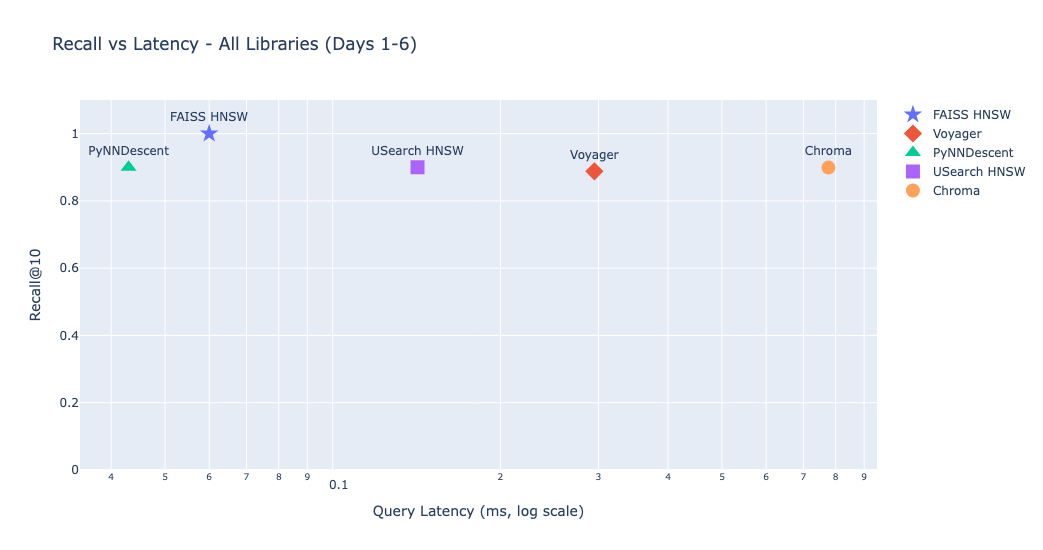

In [14]:
fig = go.Figure()

libraries = [
    {"name": "FAISS HNSW",  "x": FAISS_HNSW_LATENCY, "y": FAISS_HNSW_RECALL, "symbol": "star"},
    {"name": "Voyager",      "x": VOYAGER_LATENCY,    "y": VOYAGER_RECALL,    "symbol": "diamond"},
    {"name": "PyNNDescent",  "x": PYNND_LATENCY,      "y": PYNND_RECALL,      "symbol": "triangle-up"},
    {"name": "USearch HNSW", "x": USEARCH_LATENCY,    "y": USEARCH_RECALL,    "symbol": "square"},
    {"name": "Chroma",       "x": mean_latency,        "y": mean_recall,       "symbol": "circle"},
]

for lib in libraries:
    fig.add_trace(go.Scatter(
        x = [lib["x"]],
        y = [lib["y"]],
        mode = "markers+text",
        name = lib["name"],
        text = [lib["name"]],
        textposition = "top center",
        marker = {"size": 14, "symbol": lib["symbol"]},
    ))

fig.update_layout(
    title = "Recall vs Latency - All Libraries (Days 1-6)",
    xaxis_title = "Query Latency (ms)",
    yaxis_title = "Recall@10",
    yaxis = {"range": [0, 1.1]},
    xaxis_type = "log",
    xaxis_title_text = "Query Latency (ms, log scale)",
    width = 900,
    height = 550,
)
fig.show()

## 12. What You Would Hit in Production

Chroma in embedded mode is a single-process store. It is not designed for concurrent writes from multiple processes - if you need that, you need Chroma in client-server mode with `chromadb.HttpClient`. The transition from embedded to client-server requires no code changes to your query logic, only to the client initialization.

Chroma's HNSW implementation is solid but not the fastest available - Days 1 through 5 all showed lower latency for pure vector search. The metadata filtering and document storage are what justify the additional overhead. If you do not need filtering or persistence, PyNNDescent or FAISS will serve you faster.

Chroma Cloud offers a hosted version with serverless scaling, making it a viable path from local development to production without infrastructure management.

## 13. When to Look Elsewhere

Chroma is the wrong choice if:

- You need the lowest possible query latency - FAISS and PyNNDescent are faster for pure vector search
- Your dataset is larger than available RAM - Chroma loads indexes into memory; look at LanceDB (Day 7)
- You need concurrent writes from multiple processes in embedded mode - use client-server mode instead
- You need SQL-style joins between your vector store and relational data - LanceDB (Day 7) integrates with Arrow and has better structured data support